# Filtered $\mathrm{H^{2}MM}$ in H2MMbursts

Here we show how to use the method proposed in [Kache 2025](https://doi.org/10.1186/s44330-025-00039-2)

This will be done one the older HP3 datasets used in the other tutorials, and not on the datasets developed in Kache.

In [1]:
from itertools import chain, product

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import smfbursts as smf
import H2MMbursts as bhm

Load the data and make initial burst search:

In [2]:
raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)
dbs = smf.fretfactory.make_bg(data, period=60.0, tail_min=5e-4, auto_threshold=True, func=smf.bg.exp_mlefit, F_bg=1.7)
smf.fretfactory.make_burst_search(bg=dbs['bg'], m=10, F=6.0, update=dbs, nbva=5)
gate_All = smf.make_geq_gate(dbs['NphDex_raw'], 50) & smf.make_geq_gate(dbs['NphAA_raw'], 25)
smf.fretfactory.apply_gate(dbs, gate_All);

## Burst Examination (before doing $\mathrm{H^{2}MM}$)

Based on the outline above the burst search has been performed, but the rest of the "pre" checks have not been done. 

This section demonstrates the rest of the "pre" checks that should be done before H<sup>2</sup>MM analysis.
To see when H<sup>2</sup>MM analysis actually begins skip to the next section.
The following demonstrates the common checks done for responsible H<sup>2</sup>MM analysis.

> **Note**
> 
> In this example, all thresholds, gates etc. have been chosen before hand to be ideal based on the test data set.
> In real analysis, these are not known, and thus the following is more the minimum acceptable pre-checks.

First, we plot the E/S scatter to see the distribution of bursts.

(-0.1, 1.1)

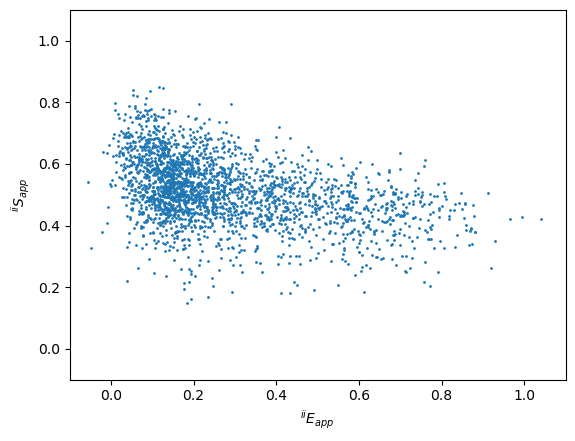

In [3]:
smf.plot.scatter(data, dbs['E_bg'], dbs['S_bg'], s=1.0)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

(0.0, 0.4)

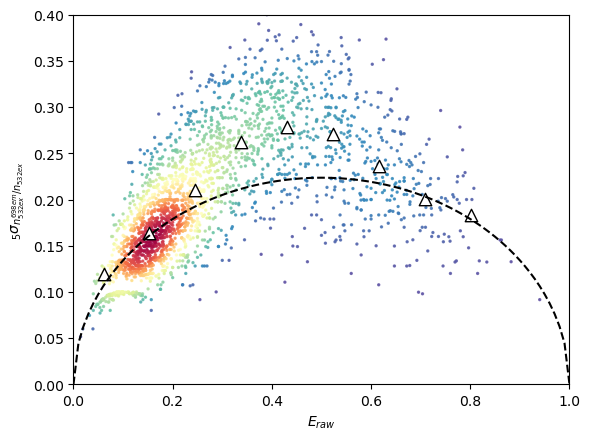

In [4]:
n = 5
x_bva = np.arange(0,1.01,0.01)
y_bva = np.sqrt((x_bva*(1-x_bva))/n)

smf.plot.scatter(data, dbs['E_raw'], dbs['BVA5'], point_func=smf.plot.density_kde, s=2.0, alpha=0.8, cmap='Spectral_r')
smf.plot.scatter_meaninterval(data, dbs['E_raw'], dbs['BVA5'], marker='^', c='w', ec='k', s=80)
plt.plot(x_bva, y_bva, ls='--', c='k')
plt.xlim([0,1])
plt.ylim([0.0, 0.4])

Note the presence of a significant number of bursts above the static FRET line.

> **Note**
>
> In [Torella 2011](https://doi.org/10.1016/j.bpj.2011.01.066)
> recomended a more computationally expensive Monte-Carlo approach to compute a static FRET confidence interval.
> This is not implemented in smfbursts or H2MMbursts, but should be relatively straitforward to implement.
> Typcially however, as BVA is already a somewhat qualatative method, using the analytical expression above is sufficient.

### Initial H<sup>2</sup>MM optimization

Typical H<sup>2</sup>MM anlaysis starts with optimizing a series of models of increasing numbers of states.
For this, the `bhm.StatePath.optimize_models()` method is used.
In the Kache paper, this is used to generate the model used to filter bursts.

This method will optimize models, and return `StatePath` based `Param`s for each optimized model.

The first two arguments `origin` and `bursts` which define the source data and the burst selection, 
as `PhotonData`/`PhotonDataList` and `Param` respectively.

The next argument is `streams`, which defines which streams of photons are given to H<sup>2</sup>MM. 

In this example, we will use the selection used in [Harris 2022](https://doi.org/10.1038/s41467-022-28632-x).
This means our streams will be $n_{Dex}^{Dem}$, $n_{Dex}^{Aem}$ and $n_{1ex}^{1em}$, ie
```python
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
```

> In the original H<sup>2</sup>MM paper [Prichi 2016](https://doi.org/10.1021/acs.jpcb.6b10726), it was demonstrated with only 2 color FRET, 
and any alternating excitation streams were discarded, ie $n_{Dex}^{Dem}$ and $n_{Dex}^{Aem}$.
>
> In a [Harris 2022](https://doi.org/10.1038/s41467-022-28632-x) (which also introduced the `H2MM_C` package on which `H2MMbursts` depends)
> it was shown that for a typical PIE measurement, also incorporating the acceptor excitation stream ($n_{Aex}^{Aem}$).
>It was also argued that any "relevant" stream will likely improve the results. 
> In other words, the more information, the better, so if a given stream is expected to differ in properties between states, it is best to include it.

The `origin`, `bursts` and `streams` arguments define the input data to the H<sup>2</sup>MM algorithm.
The remaining arguments define optimization limits parameters.
These are

1. `conv_crit='pathBIC'` criterion to use to determine if optimizations have converged
2. `to_state=4` minimum number of states to optimize, regardless of convergence criterion
3. `min_states=1` which number of states to begin optimizing at
4. `max_states=8` maximum number of states to optimize, regardless of convergence criterion
5. additional kwargs are assumed to be inputs to
   [H2MM_C.h2mm_model.optimize()](https://h2mmpythonlib.readthedocs.io/en/latest/Documentation.html#H2MM_C.h2mm_model.optimize)
   Some useful parameters are:
    1. `max_iter` set the maximum number of iterations per optimization
    2. `converged_min` set the minimum difference in loglikelihood between rounds to consder model optimized
   
Below is a typical example optimization:

In [5]:
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')) # streams to submit to H2MM analysis
statepaths = bhm.StatePath.optimize_models(
    data, dbs['bursts'], streams=streams, conv_crit='BICph', thresh=0.005
)

The model converged after 2 iterations
The model converged after 91 iterations
The model converged after 223 iterations
The model converged after 215 iterations
Optimization reached maximum number of iterations


The return value is a list of `Param` objects, based on the `StatePath` table class.

Because H<sup>2</sup>MM models typically need to be optimized first, it is rare to directly create a H<sup>2</sup>MM parameter.
Rather, we let `bhm.StatePath.optimize_models` create them from the optimized models.

Each `Param` in the list has 1 more state than the last.
Now the optimized models are examine to determine which one is the ideal model, neither over nor under fit.

After that, the ideal model can be interogated for its meaning regarding within burst dynamcs and states.

### Comparing models

There are several different statistical discriminators used for comparing the "quality" of the model.
These are:
1. $BIC$ Bayes Information Criterion of model, the loglikelhood penalized for number of parameters and datapoints
2. $ICL$ Integrated Complete Likelihood, an output of the *Viterbi* algorithm assessing the forward probabiliy of the path
3. $BIC_{path}$ BIC of most likely state-path based on *Viterbi* algorithm

The order reflects how conservative these estimators are.
Generally it is best to take all information, both from statistical discriminators, and the models themselves,
into account before selecting the ideal model.

> **Note**
>
> The `conv_crit` selection `bhm.StatePath.optimize_models()` uses the selected discriminator to determine whether to stop or not.

We can plot the statistical discriminators for a sequence of `StatePath` `Param`s with the `bhm.plot.scatter_<discr>()` functions.

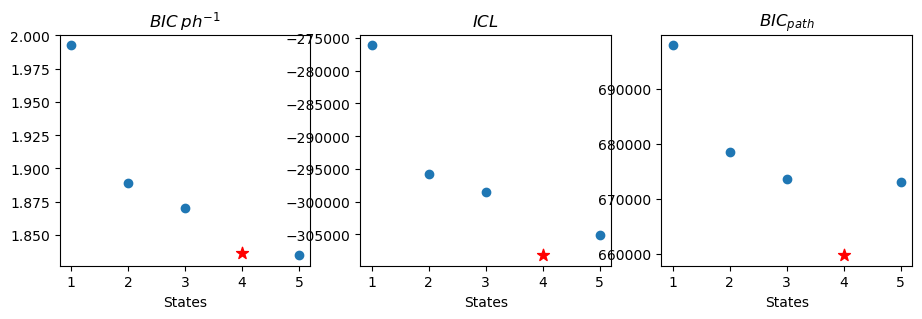

In [6]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BICph(data, statepaths, ax=ax[0], thresh=0.005)
bhm.plot.scatter_ICL(data, statepaths, ax=ax[1])
bhm.plot.scatter_pathBIC(data, statepaths, ax=ax[2]);

## Purified Optimization

### Determine States to remove

It looks like the 4 state model is the best.

We now need to visualize this model, to determine which state is which.

The method introduced by Kache is to use the *Viterbi* statepath to determine which bursts
contain blinking events (dwells in donor or acceptor only states).
So the first step is to identify these states.

(-0.1, 1.1)

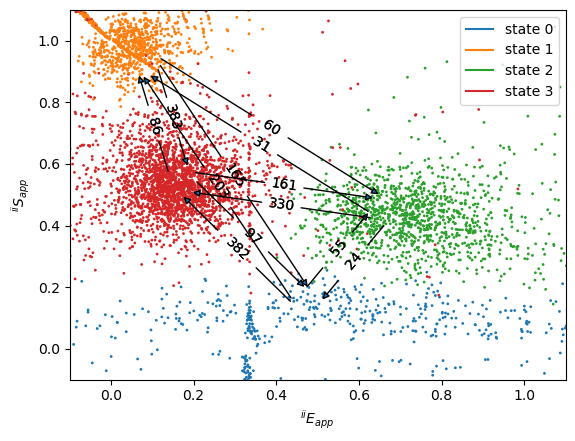

In [7]:
dwells = bhm.fretfactory.make_dwell_dict(statepaths[3])

smf.plot.scatter(data, dwells['E_bg'], dwells['S_bg'], s=1.0,
                 point_func=smf.plot.colorcategory,
                 point_cols=dwells['State'], point_kwargs={'cmap':'tab10'})

bhm.plot.scatter_model_trans_arrows(dwells['E_bg'], dwells['S_bg'], data=data)

for i in range(4):
    plt.plot(np.nan, np.nan, c=mpl.colormaps['tab10'](i), label=f'state {i}')
plt.legend()

plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

State 0 is the acceptor only, and state 1 is the donor only.
We now want to remove these bursts.
The 'bstates' column of `bhm.StatePath` is very useful here.
It is a bitcode that reports on every state in a given burst.
The bitcode has a 1 in every bit where a state is present.
This mean $\sum_{i=0}{2^{i\delta_{i}}}$ where $\delta_{i}$ is 1 if the state is present, 0 otherwise.

So to remove bursts with blinking, we simply need a gate the excludes any bitcode with these states in it.

The "isin" gate is ideal for this, as it lets us either include only certain codes.

Below is an example of how to make a set that includes only code that do **not** contain states 0 or 1.

Basically since there are 4 states, we now the possible bit codes will range from 1 to 16.
The `&` operator is a bitwise operator, so we can make a bitcode of the states we want to exclude,
and comparing it to every possible code, we can see make a test, it will be 0 only if all
states we want to exclude are not present, otherwise, we will get a non-zero number.
Thus we can 

### Create burst filter gate

(-0.1, 1.1)

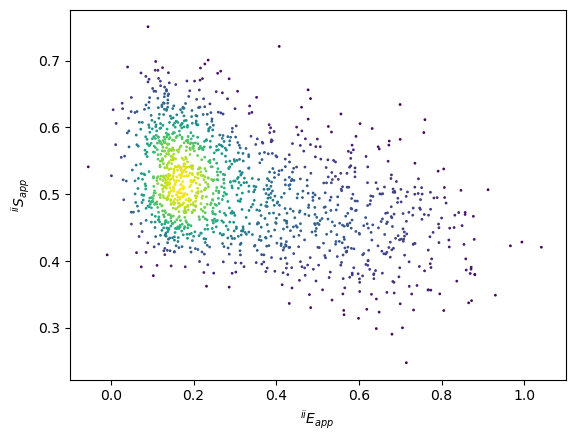

In [8]:
# range iterated over all possible bitcodes
# not i & <bitcode of all excluded bits> give us only the 
# bitcodes not containing the states we want to exclude
codes = np.array([i for i in range(1, 2**4) if not i & 0b0011])
# make the isin gate
gate_blnk = gate_All & smf.make_isin_gate(dwells['Bstates'], codes)

# make new param dictionary
dbs_blnk = smf.fretfactory.apply_gate(dbs, gate_blnk, inplace=False)

smf.plot.scatter(data, dbs_blnk['E_bg'], dbs['S_bg'], s=1.0,
                 point_func=smf.plot.density_kde)
plt.xlim([-0.1, 1.1])
plt.xlim([-0.1, 1.1])

### Filtered optimization

We can now perform a second $\mathrm{H^{2}MM}$ optimization, with the new gate

The model converged after 1 iterations
The model converged after 59 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations


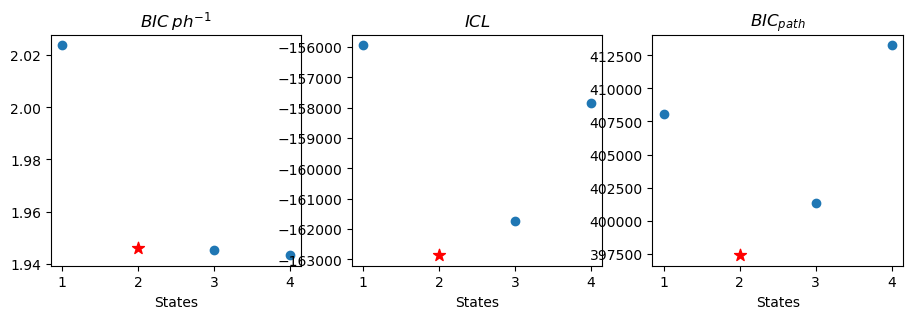

In [9]:
statepaths_blnk = bhm.StatePath.optimize_models(
    data, dbs_blnk['bursts'], streams=streams, conv_crit='BICph', thresh=0.005
)

fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BICph(data, statepaths_blnk, ax=ax[0], thresh=0.005)
bhm.plot.scatter_ICL(data, statepaths_blnk, ax=ax[1])
bhm.plot.scatter_pathBIC(data, statepaths_blnk, ax=ax[2]);

### Filtered Results

We can now examine the filtered optimized model

(-0.1, 1.1)

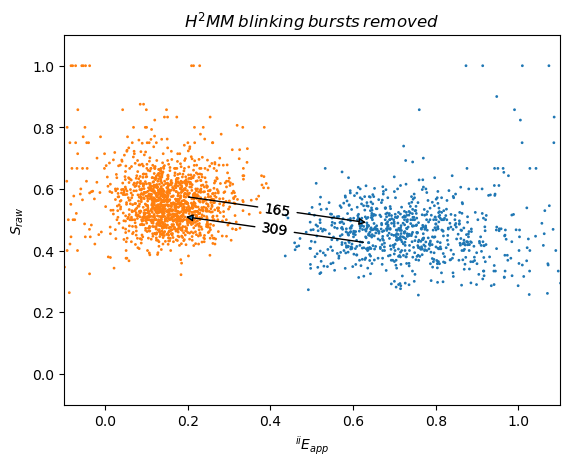

In [10]:
dwells_blnk = bhm.fretfactory.make_dwell_dict(statepaths_blnk[1])

smf.plot.scatter(data, dwells_blnk['E_bg'], dwells_blnk['S_raw'],
                 s=1.0, point_func=smf.plot.colorcategory,
                 point_cols=dwells_blnk['State'], point_kwargs={'cmap':'tab10'})

bhm.plot.scatter_model_trans_arrows(dwells_blnk['E_bg'], dwells_blnk['S_bg'],
                                    data=data)

plt.title(r"$H^{2}MM\:blinking\:bursts\:removed$")
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

## Dwell trimmed bursts

Kache also suggested, but did not implement a strategy of trimming bursts by dwells.
That is, instead of removing a burst with dwells in the blinking state, 
performing an optimization with all bursts, but removing the photons in dwells in blinked states.

H2MMbursts has a special `BasePhotonTable` class that allows us to create a "burst" selection
of just that.

This is using the `bhm.StatePathFilter`

Here, we specify the origin `bhm.StatePath` based `smf.Param` as the parent "statepath",
and the states we want to exclude using the "exclude" param (a set of the state indeces).

Below we create this param, and then run an optimization:

In [11]:
bfilt = smf.Param(bhm.StatePathFilter, statepath=statepaths[3], exclude={0,1})

statepaths_filt = bhm.StatePath.optimize_models(
    data, bfilt, streams=streams, conv_crit='BICph', thresh=0.005
)

The model converged after 1 iterations
The model converged after 64 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations


(<matplotlib.collections.PathCollection at 0x7269e3b48b30>,
 Text(0.5, 1.0, '$BIC\\:ph^{-1}$'),
 Text(0.5, 0, 'States'))

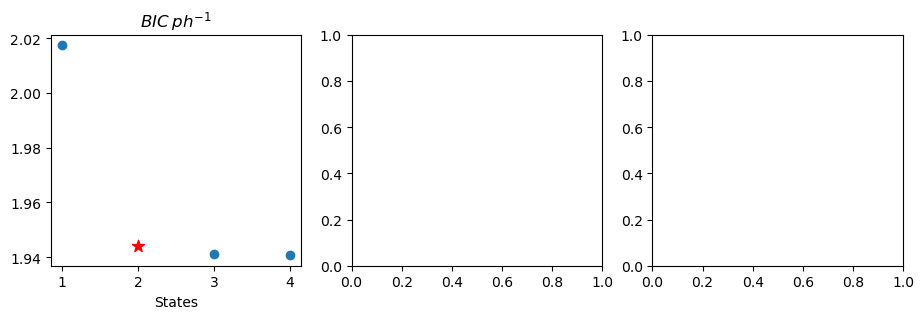

In [12]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BICph(data, statepaths_filt, ax=ax[0], thresh=0.005)

In [13]:
bhm.plot.scatter_ICL(data, statepaths_filt, ax=ax[1])
bhm.plot.scatter_pathBIC(data, statepaths_filt, ax=ax[2]);

Now we can plot and compare the results:

(-0.1, 1.1)

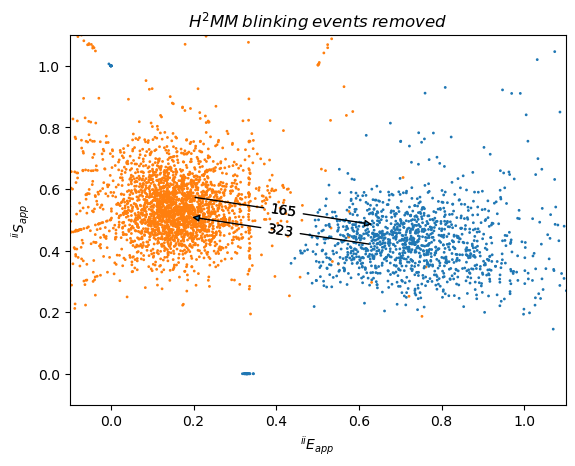

In [14]:
dwells_filt = bhm.fretfactory.make_dwell_dict(statepaths_filt[1])

smf.plot.scatter(data, dwells_filt['E_bg'], dwells_filt['S_bg'], s=1.0,
                 point_func=smf.plot.colorcategory,
                 point_cols=dwells_filt['State'], point_kwargs={'cmap':'tab10'})
bhm.plot.scatter_model_trans_arrows(dwells_filt['E_bg'], dwells_filt['S_bg'],
                                    data=data)
plt.title(r"$H^{2}MM\:blinking\:events\:removed$")
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

Now that we are done, don't forget to get the citaions:

In [15]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
5. Torella, J. P., Holden, S. J., Santoso, Y., Hohlbein, J. & Kapanidis, A. N.
    Identifying molecular dynamics in single-molecule fret experiments with
    burst variance analysis. Biophysical J. 100, 1568–1577 (2011).
6. Pirchi, M. et al. Photon-by-Phot

Thus concluded this example demonstration of Kache 2025.